In [1]:
# 第4章｜作業：Attention 神經網路：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


In [2]:
QUICK_RUN = False  # True：只訓練少量 epoch，只用來快速檢查程式能不能跑

# 作業：Attention 神經網路

**對應影片**：第 4 章 單元 10「作業：Attention 神經網路」

**和影片的差異**：Keras 3 內建 `layers.MultiHeadAttention`，不需要自己實作 Attention 層。資料與 LSTM 單元相同（加權指數日 K 的技術指標序列）。

這本是**起始 notebook**：從頭執行就會訓練出一個可以運作的 Attention 模型並回測。
你的任務寫在最後的「作業」段落。

In [3]:
import keras
import numpy as np
import pandas as pd
import talib
import finlab.ml.label as label
from finlab.backtest import sim
from keras import layers, ops
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

TRADE_STOCK = '0050'
ETF_TAX_RATIO = 0.001
HORIZON = 10
TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'
RANDOM_STATE = 0
WINDOW = 20

## 1. 準備序列資料（和 LSTM 單元相同）

In [4]:
PERIODS = [5, 10, 20, 60, 120]
STOCH_SMOOTHING = 3

taiex = pd.DataFrame({
    field: data.get(f'taiex_total_index:{name}')['TAIEX']
    for field, name in [('open', '開盤指數'), ('high', '最高指數'), ('low', '最低指數'), ('close', '收盤指數')]
}).dropna()


def technical_features(ohlc: pd.DataFrame) -> pd.DataFrame:
    high, low, close = ohlc['high'], ohlc['low'], ohlc['close']
    features = {}
    for period in PERIODS:
        slowk, slowd = talib.STOCH(high, low, close, fastk_period=period,
                                   slowk_period=STOCH_SMOOTHING, slowd_period=STOCH_SMOOTHING)
        features[f'rsi_{period}'] = talib.RSI(close, timeperiod=period)
        features[f'k_{period}'] = slowk
        features[f'd_{period}'] = slowd
        features[f'willr_{period}'] = talib.WILLR(high, low, close, timeperiod=period)
        features[f'cci_{period}'] = talib.CCI(high, low, close, timeperiod=period)
        features[f'roc_{period}'] = talib.ROC(close, timeperiod=period)
        features[f'sma_bias_{period}'] = close / talib.SMA(close, timeperiod=period)
        features[f'wma_bias_{period}'] = close / talib.WMA(close, timeperiod=period)
        features[f'atr_ratio_{period}'] = talib.ATR(high, low, close, timeperiod=period) / close
    macd, macd_signal, macd_hist = talib.MACD(close)
    features['macd'] = macd / close
    features['macd_signal'] = macd_signal / close
    features['macd_hist'] = macd_hist / close
    return pd.DataFrame(features)


def forward_return(dates: pd.DatetimeIndex, period: int) -> pd.Series:
    index = pd.MultiIndex.from_product([dates, [TRADE_STOCK]], names=['datetime', 'instrument'])
    return label.return_percentage(index, period=period).droplevel('instrument')


features = technical_features(taiex)
feature_names = list(features.columns)
dataset = features.assign(future_return=forward_return(features.index, HORIZON)).dropna()
dataset['up'] = dataset['future_return'] > 0

scaler = StandardScaler().fit(dataset.loc[:TRAIN_END, feature_names])
X = sliding_window_view(scaler.transform(dataset[feature_names]), WINDOW, axis=0).transpose(0, 2, 1)
y = dataset['up'].to_numpy()[WINDOW - 1:]
sample_dates = dataset.index[WINDOW - 1:]

is_train, is_test = sample_dates <= TRAIN_END, sample_dates >= TEST_START
X_train, y_train, X_test, y_test = X[is_train], y[is_train], X[is_test], y[is_test]
print(f'訓練 {len(X_train)} 筆、測試 {len(X_test)} 筆，每筆 {WINDOW} 天 × {len(feature_names)} 個特徵')

訓練 2143 筆、測試 726 筆，每筆 20 天 × 48 個特徵


## 2. Attention 模型

Self-attention 讓序列中的每一天，都能直接參考其他每一天的資訊，並自己學習「該注意哪幾天」。

1. `Dense` 把每天的特徵投影成 `MODEL_DIM` 維。
2. 加上**位置編碼**：Attention 本身不知道先後順序，所以替每個位置加上一組可學習的向量。
3. `MultiHeadAttention` + 殘差連接 + `LayerNormalization`，再接一個前饋網路（Transformer encoder 的基本結構）。
4. 把所有位置平均後輸出上漲機率。

In [5]:
class PositionalEmbedding(layers.Layer):
    """替序列中每個位置加上一組可學習的向量。"""

    def __init__(self, sequence_length: int, dim: int, **kwargs):
        super().__init__(**kwargs)
        self.position_embedding = layers.Embedding(sequence_length, dim)

    def call(self, inputs):
        positions = ops.arange(ops.shape(inputs)[1])
        return inputs + self.position_embedding(positions)


MODEL_DIM = 32
NUM_HEADS = 4
DROPOUT = 0.3
LEARNING_RATE = 1e-3


def build_attention_model() -> keras.Model:
    keras.utils.set_random_seed(RANDOM_STATE)
    inputs = keras.Input(shape=X.shape[1:])
    x = layers.Dense(MODEL_DIM)(inputs)
    x = PositionalEmbedding(WINDOW, MODEL_DIM)(x)

    attention = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=MODEL_DIM // NUM_HEADS, dropout=DROPOUT)(x, x)
    x = layers.LayerNormalization()(x + attention)
    feed_forward = layers.Dense(MODEL_DIM, activation='relu')(x)
    x = layers.LayerNormalization()(x + layers.Dropout(DROPOUT)(feed_forward))

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model


model = build_attention_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 48)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 32)    │      1,568 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 20, 32)    │        640 │ dense[0][0]       │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 32)    │      4,224 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 32)    │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 32)    │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 20, 32)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,649 (29.88 KB)

 Trainable params: 7,649 (29.88 KB)

 Non-trainable params: 0 (0.00 B)

## 3. 訓練

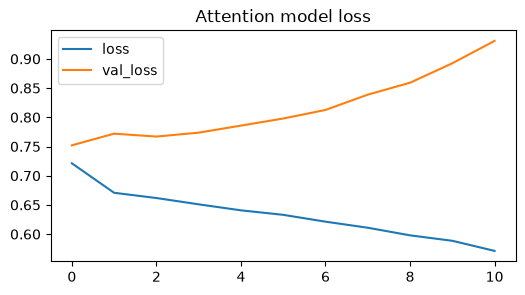

In [6]:
EPOCHS = 2 if QUICK_RUN else 100
BATCH_SIZE = 64
VALIDATION_FRACTION = 0.2
PATIENCE = 10

history = model.fit(
    X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)],
    verbose=0,
)
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(6, 3), title='Attention model loss');

In [7]:
train_probability = pd.Series(model.predict(X_train, verbose=0).ravel(), index=sample_dates[is_train])
test_probability = pd.Series(model.predict(X_test, verbose=0).ravel(), index=sample_dates[is_test])
print(f'訓練 AUC：{roc_auc_score(y_train, train_probability):.3f}')
print(f'測試 AUC：{roc_auc_score(y_test, test_probability):.3f}')

訓練 AUC：0.553
測試 AUC：0.496


## 4. 回測

In [8]:
SIGNAL_QUANTILE = 0.7

threshold = train_probability.quantile(SIGNAL_QUANTILE)
hold = (test_probability > threshold).rolling(HORIZON, min_periods=1).max().astype(bool)
position = hold.to_frame(TRADE_STOCK)

strategy = sim(position, name='Attention timing', tax_ratio=ETF_TAX_RATIO)
buy_and_hold = sim(position.notna(), name='Buy & hold 0050', tax_ratio=ETF_TAX_RATIO)

pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in [('Attention timing', strategy), ('Buy & hold 0050', buy_and_hold)]
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
Attention timing,5.26%,-16.05%,0.40
Buy & hold 0050,11.50%,-14.96%,0.72


## 作業

1. **調整結構**：改變 `NUM_HEADS`、`MODEL_DIM`，或把 Attention 區塊疊兩層。驗證 loss 有沒有變低？
2. **拿掉位置編碼**：把 `PositionalEmbedding` 那一行刪掉再訓練一次，結果差多少？為什麼？
3. **和 LSTM 比較**：用同樣的 `WINDOW` 與特徵，比較 Attention 與 LSTM 單元的測試 AUC 和回測結果。
4. **看模型注意哪幾天**：`layers.MultiHeadAttention(...)(x, x, return_attention_scores=True)` 會多回傳注意力權重，試著把最後一個樣本的權重畫成熱度圖。

提醒：挑選設定只能看驗證資料；測試期間的結果只在最後看一次，才不會不知不覺地過度最佳化。